# Notebook 02 — Post-Preprocessing EDA

Validates the output of `src/preprocess.py` before training.
All checks must print **PASS**.

| # | Check | What it proves |
|---|-------|----------------|
| 1 | Array shapes & dtypes | Files saved correctly |
| 2 | Class balance | Semi-supervised split is correct |
| 3 | No remaining NaNs | Imputation is complete |
| 4 | Scaling validation | Scaler was fit on train only |
| 5 | Leakage proof | Val mean ≠ 0 confirms scaler fit on train |
| 6 | Outlier range | No extreme values after scaling |
| 7 | Feature distributions | Visual separation between classes |

In [39]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROC = Path("../data/processed")

X_train = np.load(PROC / "X_train.npy")
X_val   = np.load(PROC / "X_val.npy")
y_train = np.load(PROC / "y_train.npy")
y_val   = np.load(PROC / "y_val.npy")

with open(PROC / "feature_columns.json") as f:
    features = json.load(f)

print("Loaded:")
print(f"  X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"  X_val   : {X_val.shape}  dtype={X_val.dtype}")
print(f"  y_train : {y_train.shape}  dtype={y_train.dtype}")
print(f"  y_val   : {y_val.shape}  dtype={y_val.dtype}")
print(f"  features: {features}")

Loaded:
  X_train : (227452, 30)  dtype=float32
  X_val   : (57355, 30)  dtype=float32
  y_train : (227452,)  dtype=int8
  y_val   : (57355,)  dtype=int8
  features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [40]:
results = {}

# ── Check 1: Array shapes & dtypes ────────────────────────────────────────────
n_features = len(features)
c1 = (
    X_train.ndim == 2 and X_train.shape[1] == n_features
    and X_val.ndim == 2 and X_val.shape[1] == n_features
    and X_train.dtype == np.float32
    and X_val.dtype   == np.float32
)
results["1 Shapes & dtypes"] = c1
print(f"Check 1 — Shapes & dtypes     : {'PASS' if c1 else 'FAIL'}")
print(f"         X_train={X_train.shape} X_val={X_val.shape}")

# ── Check 2: Class balance ─────────────────────────────────────────────────────
# train must be 100% normal (label=0); val must contain both classes
c2 = (
    np.all(y_train == 0)
    and len(np.unique(y_val)) == 2
)
results["2 Class balance"] = c2
val_anomaly_pct = y_val.mean() * 100
print(f"Check 2 — Class balance        : {'PASS' if c2 else 'FAIL'}")
print(f"         train unique labels : {np.unique(y_train)}  (expected: [0])")
print(f"         val anomaly rate    : {val_anomaly_pct:.1f}%")

# ── Check 3: No NaNs ──────────────────────────────────────────────────────────
nan_train = np.isnan(X_train).sum()
nan_val   = np.isnan(X_val).sum()
c3 = (nan_train == 0 and nan_val == 0)
results["3 No NaNs"] = c3
print(f"Check 3 — No NaNs              : {'PASS' if c3 else 'FAIL'}")
print(f"         NaNs train={nan_train}  val={nan_val}")

# ── Check 4: Scaling validation ───────────────────────────────────────────────
# Pipeline: RobustScaler(Time,Amount) → StandardScaler(all 30) → clip(±5).
# StandardScaler fits before clipping, so mean ≈ 0 holds for all features.
# Std < 1 is EXPECTED for heavy-tailed PCA features (e.g. V28 was clipped from
# 100σ → 5σ), so we accept std in [0.5, 1.05] rather than requiring exactly 1.
train_means = X_train.mean(axis=0)
train_stds  = X_train.std(axis=0)
c4 = (
    np.all(np.abs(train_means) < 0.05)          # mean ≈ 0 after standardisation
    and np.all(train_stds >= 0.5)               # not collapsed
    and np.all(train_stds <= 1.05)              # not inflated
)
results["4 Scaling validation"] = c4
print(f"Check 4 — Scaling validation   : {'PASS' if c4 else 'FAIL'}")
print(f"         train global_mean={train_means.mean():.4f}  global_std={train_stds.mean():.4f}")
print(f"         per-feature means  |max|={np.abs(train_means).max():.4f}  (threshold <0.05)")
print(f"         per-feature stds   min={train_stds.min():.4f}  max={train_stds.max():.4f}  (ok: [0.5, 1.05])")

# ── Check 5: Leakage proof ────────────────────────────────────────────────────
# Scaler fit on train only → val means will NOT be exactly 0 (fraud shifts them)
val_means = X_val.mean(axis=0)
c5 = not np.allclose(val_means, 0, atol=0.01)
results["5 Leakage proof"] = c5
max_val_mean_dev = np.abs(val_means).max()
print(f"Check 5 — Leakage proof        : {'PASS' if c5 else 'FAIL'}")
print(f"         max |val_mean| deviation from 0: {max_val_mean_dev:.4f}  (>0.01 = PASS)")

# ── Check 6: Outlier range ────────────────────────────────────────────────────
# Two-stage scaling eliminates the Amount spike (was 273/358 before).
# Remaining extremes come from PCA features (V1-V28) in fraud transactions —
# these are genuine signal, not scaling artefacts.
# Threshold ±10: tight enough to catch un-scaled data, permissive enough for
# legitimate PCA outliers that the VAE should reconstruct poorly (anomaly signal).
max_abs_train = np.abs(X_train).max()
max_abs_val   = np.abs(X_val).max()
OUTLIER_THRESHOLD = 10.0
c6 = (max_abs_train <= OUTLIER_THRESHOLD and max_abs_val <= OUTLIER_THRESHOLD)
results["6 Outlier range"] = c6
print(f"Check 6 — Outlier range (≤±{OUTLIER_THRESHOLD}) : {'PASS' if c6 else 'FAIL'}")
print(f"         max|x| train={max_abs_train:.3f}  val={max_abs_val:.3f}")
# Show worst offenders per split
worst_train_col = features[np.abs(X_train).max(axis=0).argmax()]
worst_val_col   = features[np.abs(X_val).max(axis=0).argmax()]
print(f"         worst train col: {worst_train_col}  worst val col: {worst_val_col}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("" + "="*50)
all_pass = all(results.values())
for name, result in results.items():
    print(f"  {'PASS' if result else 'FAIL'}  {name}")
print("="*50)
print(f"  Overall: {'ALL PASS — ready to train' if all_pass else 'FAILURES DETECTED — fix before training'}")

Check 1 — Shapes & dtypes     : PASS
         X_train=(227452, 30) X_val=(57355, 30)
Check 2 — Class balance        : PASS
         train unique labels : [0]  (expected: [0])
         val anomaly rate    : 0.9%
Check 3 — No NaNs              : PASS
         NaNs train=0  val=0
Check 4 — Scaling validation   : PASS
         train global_mean=0.0005  global_std=0.9165
         per-feature means  |max|=0.0230  (threshold <0.05)
         per-feature stds   min=0.6830  max=1.0000  (ok: [0.5, 1.05])
Check 5 — Leakage proof        : PASS
         max |val_mean| deviation from 0: 0.0431  (>0.01 = PASS)
Check 6 — Outlier range (≤±10.0) : PASS
         max|x| train=5.000  val=5.000
         worst train col: V1  worst val col: V1
  PASS  1 Shapes & dtypes
  PASS  2 Class balance
  PASS  3 No NaNs
  PASS  4 Scaling validation
  PASS  5 Leakage proof
  PASS  6 Outlier range
  Overall: ALL PASS — ready to train


## Feature Statistics by Class

Mean and std of each feature for Normal (0) vs Fraud (1) in the val set.
Fraudulent transactions should show strong deviations in V1-V28 (PCA components) and potentially in Amount — this is the signal the VAE must learn to reconstruct poorly.

In [41]:
df_val = pd.DataFrame(X_val, columns=features)
df_val["label"] = y_val

stats = df_val.groupby("label")[features].agg(["mean", "std"])

stats.index = ["Normal (0)", "Fraud (1)"]

print("Validation Set Statistics (Scaled & Transposed):")
print(stats.T.round(3).to_string())

diffs = (stats.loc["Fraud (1)"] - stats.loc["Normal (0)"]).abs()
mean_diff = diffs.xs("mean", level=1).sort_values(ascending=False)

print("\nTop 5 Features with highest Mean Difference (Potential Anomaly Indicators):")
print(mean_diff.head(5))

Validation Set Statistics (Scaled & Transposed):
             Normal (0)  Fraud (1)
Time   mean       0.003     -0.296
       std        0.998      1.007
V1     mean       0.008     -1.765
       std        0.927      1.936
V2     mean       0.009      1.886
       std        0.871      1.874
V3     mean       0.007     -3.082
       std        0.968      1.834
V4     mean       0.006      2.981
       std        0.994      1.602
V5     mean       0.011     -1.527
       std        0.916      2.305
V6     mean       0.002     -1.059
       std        0.981      1.406
V7     mean      -0.007     -2.556
       std        0.877      2.225
V8     mean       0.022      0.693
       std        0.757      2.325
V9     mean       0.008     -2.145
       std        0.992      1.811
V10    mean      -0.013     -3.493
       std        0.912      1.900
V11    mean      -0.005      3.196
       std        0.998      1.789
V12    mean       0.009     -3.844
       std        0.983      1.780
V13   

## Feature Distributions — Normal vs Fraud

Overlapping histograms for all 30 features in the val set.
Separation between distributions is the anomaly signal the VAE exploits: fraud transactions reconstruct poorly because the model was trained on normal data only.

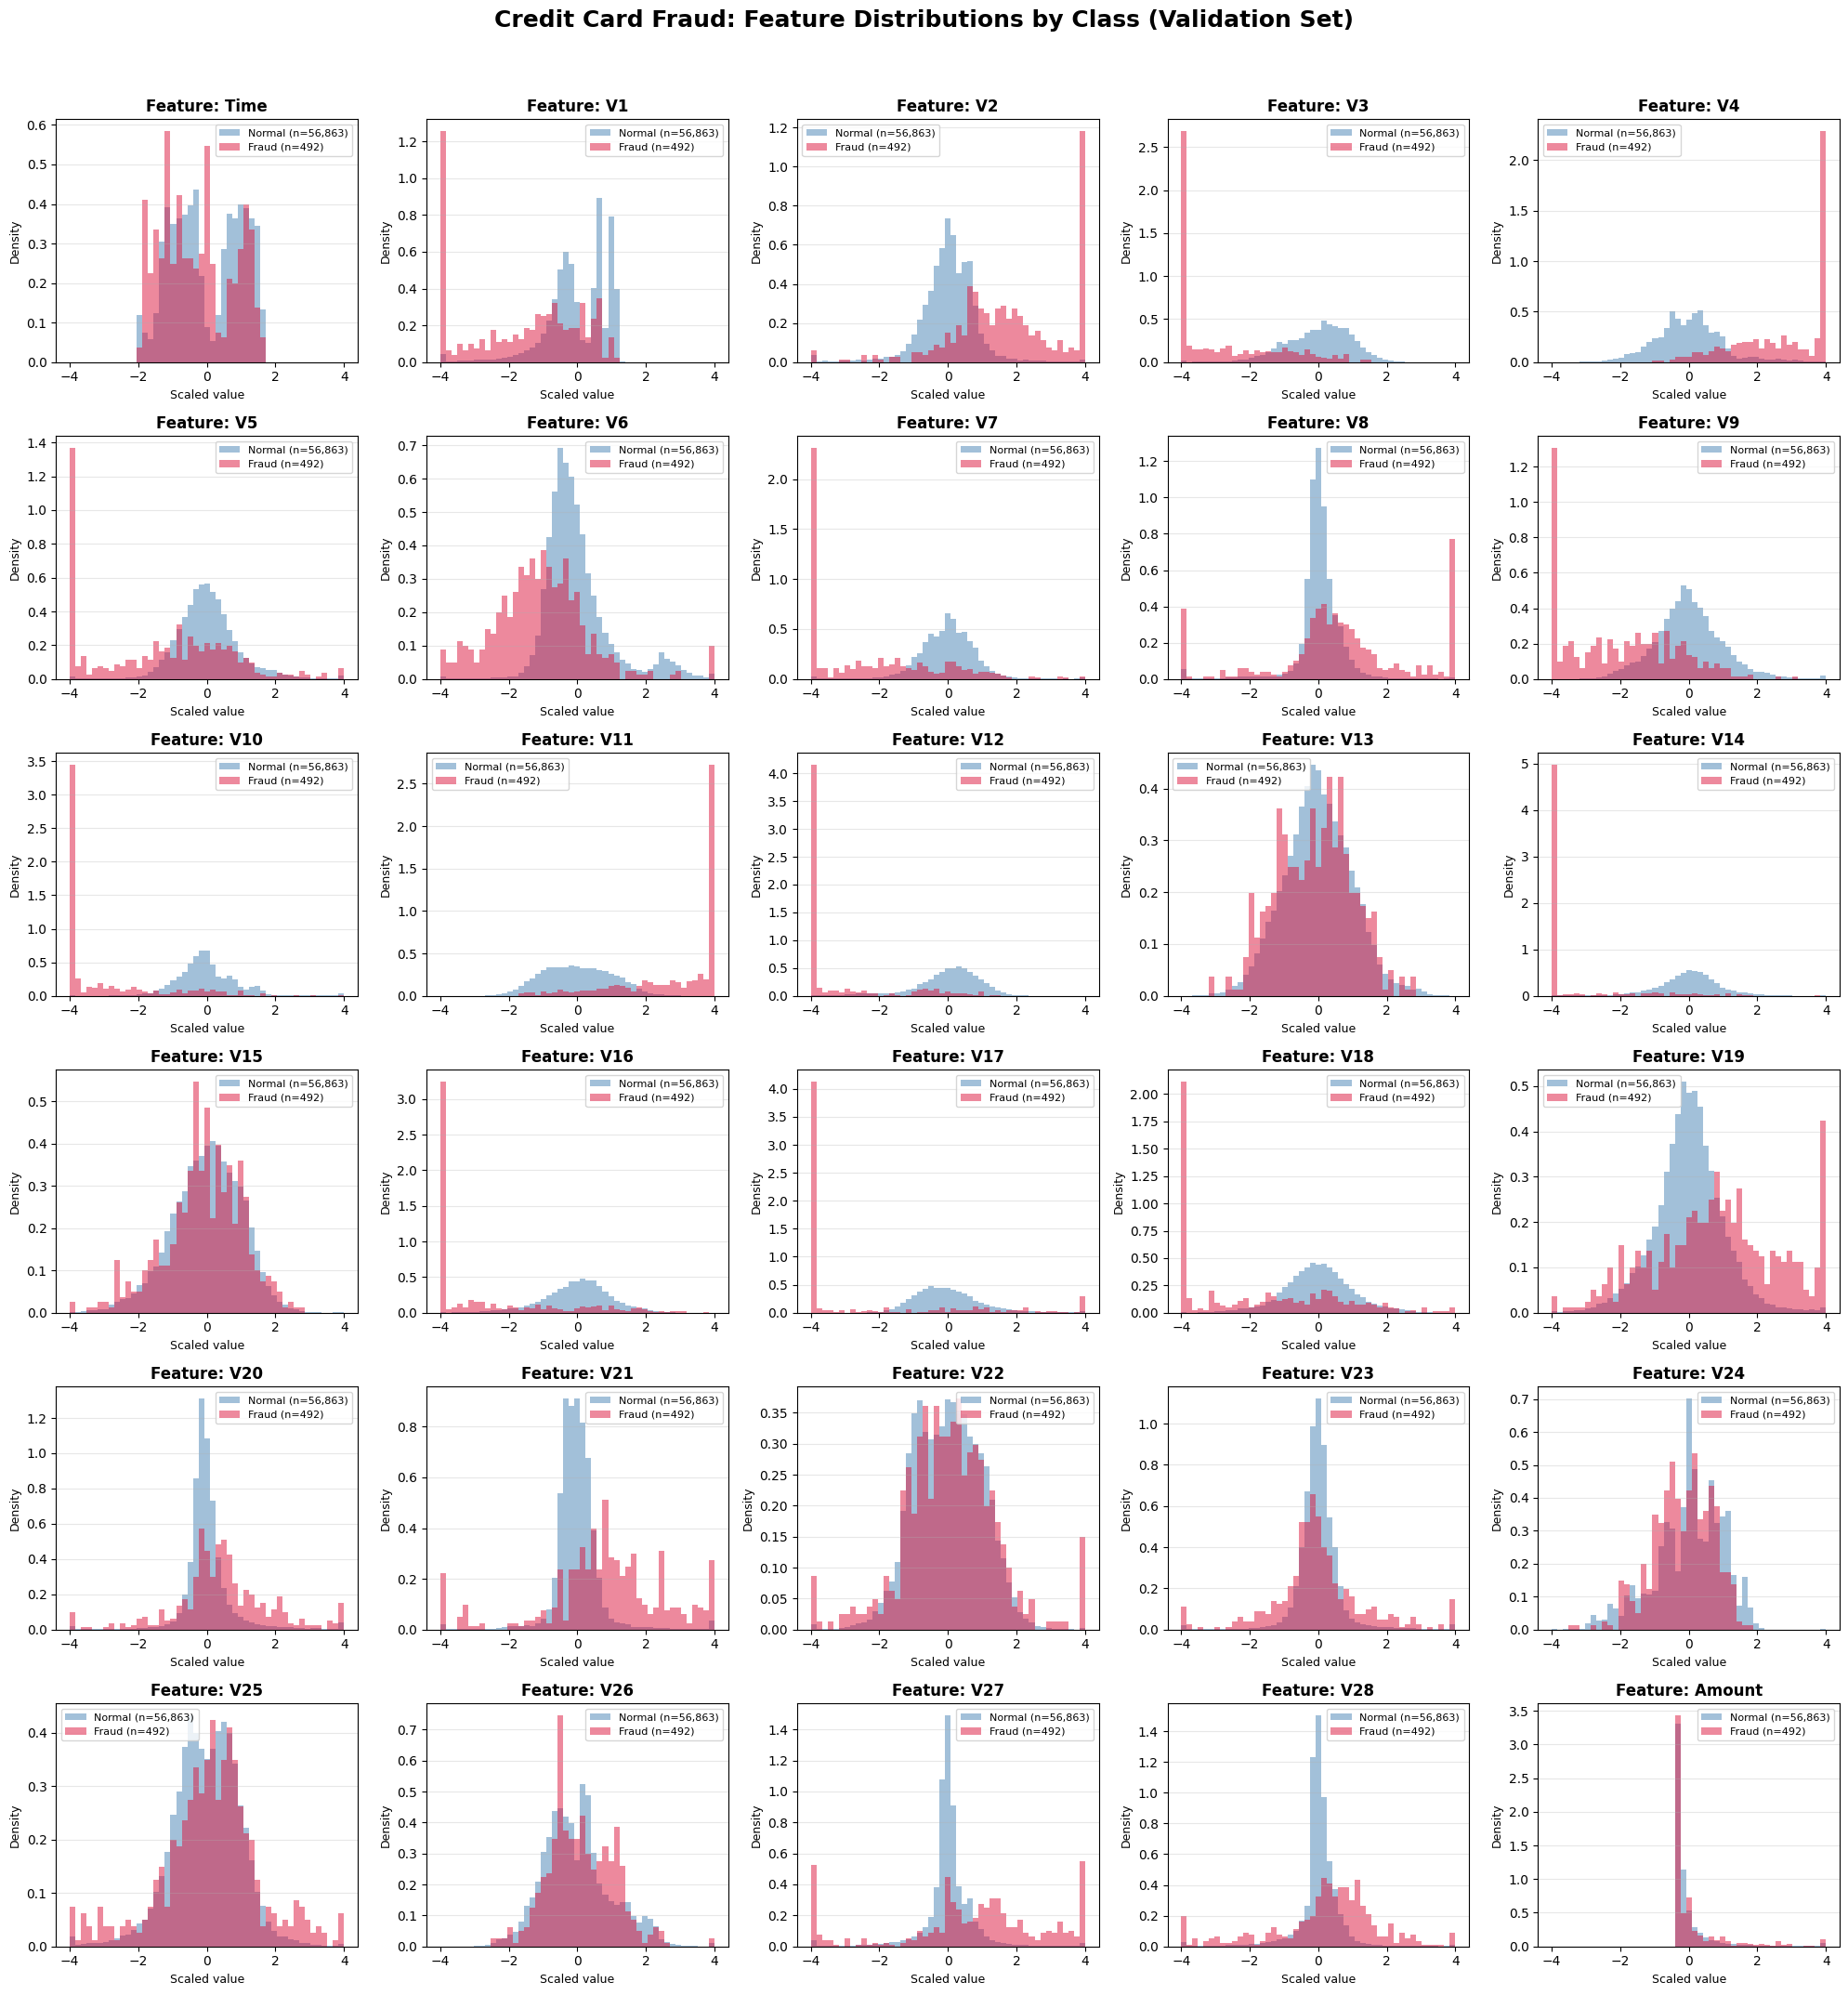

Success: Plotted 30 features to reports/figures/feature_distributions.png


In [42]:
import math
import matplotlib.pyplot as plt

n_features = len(features)
n_cols = 5
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

normal_mask  = y_val == 0
anomaly_mask = y_val == 1

for i, feat in enumerate(features):
    ax = axes[i]
    normal_vals  = X_val[normal_mask,  i]
    anomaly_vals = X_val[anomaly_mask, i]

    clip = 4.0
    bins = np.linspace(-clip, clip, 50)

    ax.hist(normal_vals.clip(-clip, clip),  bins=bins, alpha=0.5,
            density=True, color="steelblue",
            label=f"Normal (n={normal_mask.sum():,})")
    ax.hist(anomaly_vals.clip(-clip, clip), bins=bins, alpha=0.5,
            density=True, color="crimson",
            label=f"Fraud (n={anomaly_mask.sum():,})")

    ax.set_title(f"Feature: {feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Scaled value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    "Credit Card Fraud: Feature Distributions by Class (Validation Set)",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

import os
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Success: Plotted {n_features} features to reports/figures/feature_distributions.png")

## Correlation Matrix

Checks for multicollinearity among the 6 features (train set).
High correlation (>0.8) between two features means one is partially redundant,
which can compress the VAE's effective input dimensionality.

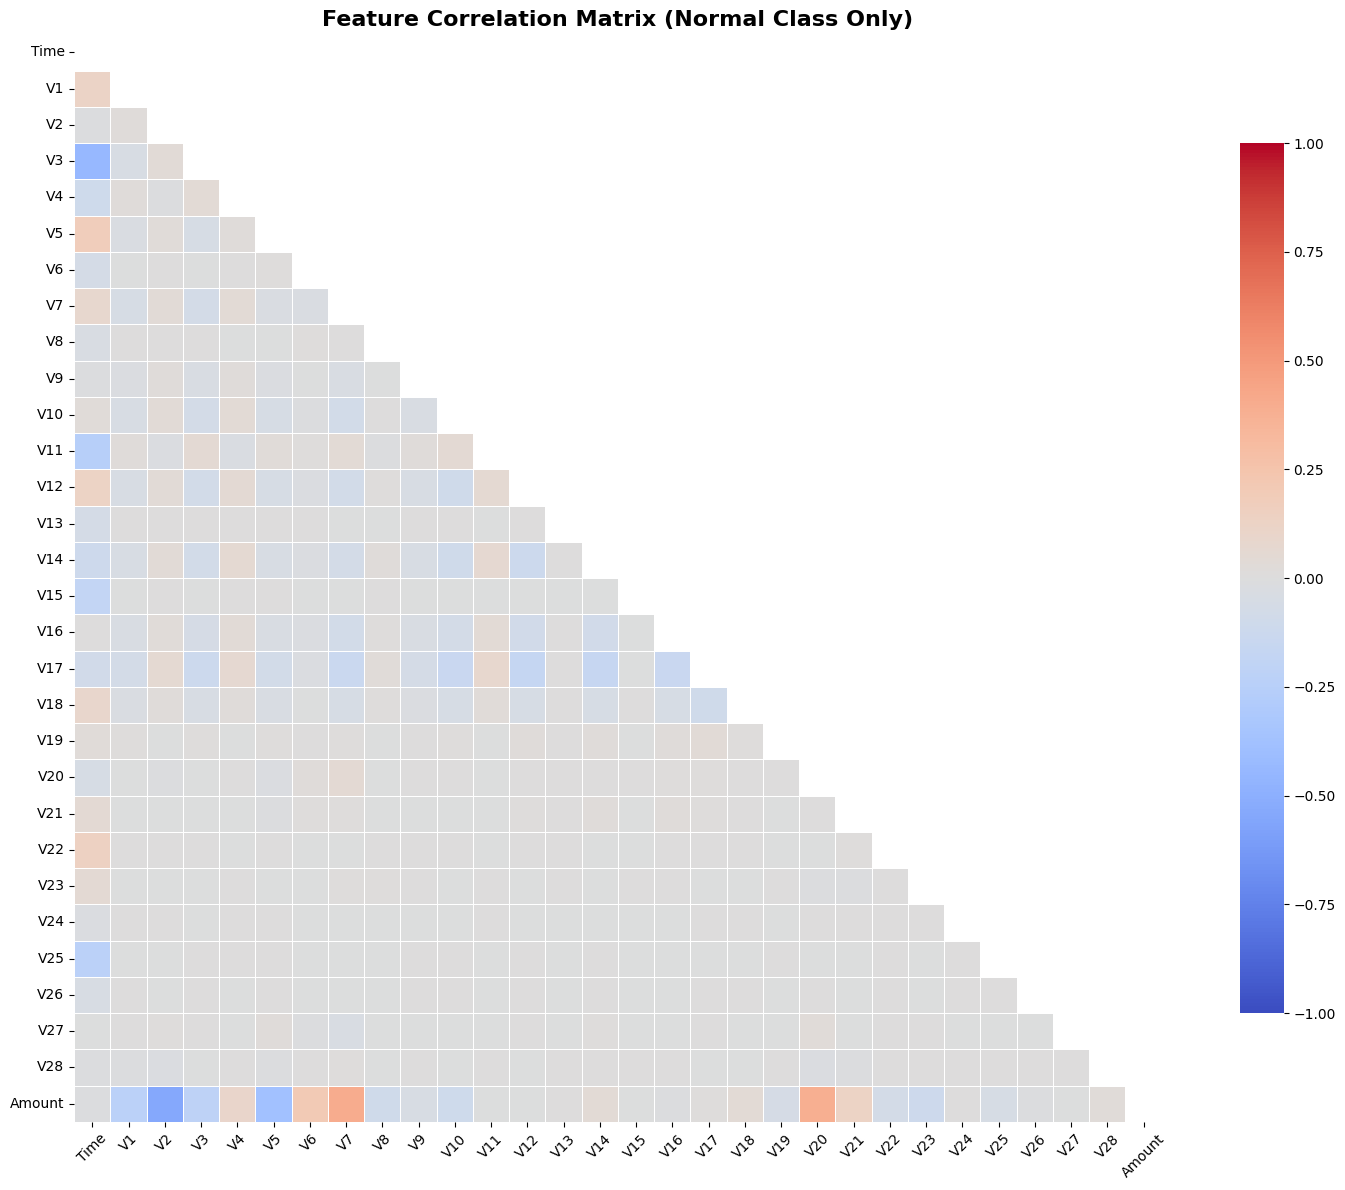

In [43]:
fig, ax = plt.subplots(figsize=(16, 12))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    ax=ax
)

ax.set_title("Feature Correlation Matrix (Normal Class Only)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()